# 05 — Output

Turn the disambiguated toponym instances from `04_disambiguation.ipynb` into
shareable artifacts:

- a flat **CSV** of resolved toponym instances merged with article metadata
- a **GeoJSON** of unique resolved places, ready for GIS tools
- descriptive statistics and charts
- an interactive **Folium** map

Only records with a known gazetteer source (`pleiades` or `geonames`) are
kept — `unresolved` toponyms are excluded from these outputs.

## CONFIG

In [1]:
import json
import logging
from pathlib import Path

import folium
import jsonlines
import matplotlib.pyplot as plt
import pandas as pd

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("aec_geoparser.output")

DISAMBIGUATED  = Path("../data/results/disambiguated.jsonl")
ARTICLES_CACHE = Path("../data/cache/articles_with_abstract.jsonl")
OUT_CSV        = Path("../data/results/aec_toponyms.csv")
OUT_GEOJSON    = Path("../data/results/aec_toponyms.geojson")
OUT_MAP        = Path("../data/results/map.html")


## Load, filter and merge

Keep only resolved toponym instances and join them with article metadata (`title, publication_year, authors, doi, url, language`) on `article_id`.

In [2]:
def load_jsonl(path: Path) -> pd.DataFrame:
    """Load a JSONL file into a DataFrame."""
    with jsonlines.open(path) as reader:
        return pd.DataFrame(list(reader))


disambiguated = load_jsonl(DISAMBIGUATED)
articles = load_jsonl(ARTICLES_CACHE).rename(columns={"id": "article_id"})

resolved = disambiguated[disambiguated["gazetteer_source"] != "unresolved"].copy()

article_meta = articles[["article_id", "title", "publication_year", "authors", "doi", "url", "language"]]
merged = resolved.merge(article_meta, on="article_id", how="left")

logger.info("%d resolved toponym instances out of %d total", len(resolved), len(disambiguated))


2026-06-09 08:33:51,481 [INFO] 1020 resolved toponym instances out of 1308 total


## Save CSV

In [3]:
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
merged.to_csv(OUT_CSV, index=False)
print(f"Saved {len(merged)} rows to {OUT_CSV}")
merged.head()


Saved 1020 rows to ../data/results/aec_toponyms.csv


,article_id,toponym_raw,toponym_normalized,entity_type,context_fragment,ner_confidence,pleiades_uri,pleiades_name,pleiades_place_types,geonames_id,...,lat,lon,disambiguation_method,disambiguation_confidence,title,publication_year,authors,doi,url,language
0,7,Etruscan,Etruria,region,"A survey of the projects carried out, with emp...",high,https://pleiades.stoa.org/places/413122,Etruria/Tuscia (region),[region],NaN,...,42.673438,11.533775,exact,high,L'analisi quantitativa nell'archeologia di epo...,1990,"[{'first_name': 'Paola', 'last_name': 'Moscati'}]",NaN,https://www.archcalc.cnr.it/journal/articles/7,ita
1,9,Salento,Salento,region,Methodological and statistical aspects of the ...,high,NaN,NaN,None,3168677.0,...,40.500000,18.000000,geonames,low,Note sulla distribuzione delle ceramiche di im...,1990,"[{'first_name': 'Grazia', 'last_name': 'Semera...",,https://www.archcalc.cnr.it/journal/articles/9,ita
2,11,Velia,Velia,settlement,The authors describe in particular the test ca...,high,https://pleiades.stoa.org/places/452488,Velia/Elea,[settlement],NaN,...,40.160501,15.156157,llm,low,Un calcolatore disegna e registra ceramica ant...,1990,"[{'first_name': 'Fritz ', 'last_name': 'Krinzi...",,https://www.archcalc.cnr.it/journal/articles/11,ita
3,15,Castelraimondo,Castelraimondo,site,It was used for data storage and retrieval dur...,high,https://pleiades.stoa.org/places/187340,Castelraimondo,[settlement],NaN,...,46.223943,12.973739,exact,high,ALADINO: verso un sistema computerizzato per l...,1990,"[{'first_name': 'Maria Pia', 'last_name': 'Gue...",NaN,https://www.archcalc.cnr.it/journal/articles/15,ita
4,25,Iberian Peninsula,Iberian Peninsula,region,The determination of cultural groups is reveal...,high,https://pleiades.stoa.org/places/540456066,Iberia (modern region/peninsula),[peninsula],NaN,...,40.000000,-5.000000,exact,high,Contribución de análisis estadisticos para la ...,1991,"[{'first_name': 'Jesús V.', 'last_name': 'Pica...",NaN,https://www.archcalc.cnr.it/journal/articles/25,spa


## Build GeoJSON of unique places

Group resolved instances by place identifier (Pleiades URI or GeoNames ID), and emit one Point feature per unique place with aggregated article-level properties.

In [4]:
def place_key(row) -> tuple:
    """Identify a unique place by Pleiades URI if present, else GeoNames ID."""
    if row["gazetteer_source"] == "pleiades":
        return ("pleiades", row["pleiades_uri"])
    return ("geonames", row["geonames_id"])


merged["_place_key"] = merged.apply(place_key, axis=1)

features = []
for _key, group in merged.groupby("_place_key"):
    first = group.iloc[0]
    article_ids = sorted(group["article_id"].unique().tolist())
    years = sorted(int(y) for y in group["publication_year"].dropna().unique().tolist())

    feature = {
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [first["lon"], first["lat"]],
        },
        "properties": {
            "pleiades_uri": first["pleiades_uri"],
            "geonames_id": (int(first["geonames_id"]) if pd.notna(first["geonames_id"]) else None),
            "pleiades_name": first["pleiades_name"],
            "geonames_name": first["geonames_name"],
            "pleiades_place_types": first["pleiades_place_types"],
            "lat": first["lat"],
            "lon": first["lon"],
            "gazetteer_source": first["gazetteer_source"],
            "article_count": len(article_ids),
            "article_ids": article_ids,
            "years": years,
            "first_year": (years[0] if years else None),
            "last_year": (years[-1] if years else None),
        },
    }
    features.append(feature)

geojson = {"type": "FeatureCollection", "features": features}
OUT_GEOJSON.write_text(json.dumps(geojson, ensure_ascii=False, indent=2))
print(f"Saved {len(features)} unique places to {OUT_GEOJSON}")


Saved 474 unique places to ../data/results/aec_toponyms.geojson


## Descriptive statistics

In [5]:
places_df = pd.DataFrame([f["properties"] for f in features])

print(f"Total unique places identified:    {len(places_df)}")
print(f"Total resolved toponym instances:  {len(merged)}")


Total unique places identified:    474
Total resolved toponym instances:  1020


In [6]:
top20 = places_df.sort_values("article_count", ascending=False).head(20)

print("Top 20 most cited places:")
for _, row in top20.iterrows():
    name = row["pleiades_name"] or row["geonames_name"]
    identifier = row["pleiades_uri"] or row["geonames_id"]
    print(f"  {name:<30} {identifier}   articles={row['article_count']}")


Top 20 most cited places:
  Etruria/Tuscia (region)        https://pleiades.stoa.org/places/413122   articles=38
  Roma                           https://pleiades.stoa.org/places/423025   articles=33
  Caere                          https://pleiades.stoa.org/places/422859   articles=20
  Pompeii                        https://pleiades.stoa.org/places/433032   articles=18
  Latium (region)                https://pleiades.stoa.org/places/432900   articles=17
  Kainua                         https://pleiades.stoa.org/places/393448   articles=13
  Tiberis (river)                https://pleiades.stoa.org/places/423080   articles=12
  Sicilia (island)               https://pleiades.stoa.org/places/462492   articles=11
  Campania                       https://pleiades.stoa.org/places/432742   articles=10
  Doclea                         https://pleiades.stoa.org/places/481808   articles=9
  Hierapolis/Pamukkale           https://pleiades.stoa.org/places/638860   articles=9
  Phrygia          

In [7]:
merged["decade"] = (merged["publication_year"] // 10 * 10).astype("Int64")
disambiguated["decade"] = (
    disambiguated.merge(article_meta[["article_id", "publication_year"]], on="article_id", how="left")
    ["publication_year"] // 10 * 10
).astype("Int64")

resolution_by_decade = (
    disambiguated.assign(resolved=disambiguated["gazetteer_source"] != "unresolved")
    .groupby("decade")["resolved"]
    .mean()
    .mul(100)
    .round(1)
)
print("Resolution rate by decade (%):")
print(resolution_by_decade.to_string())


Resolution rate by decade (%):
decade
1990    75.7
2000    80.1
2010    76.5
2020    79.7


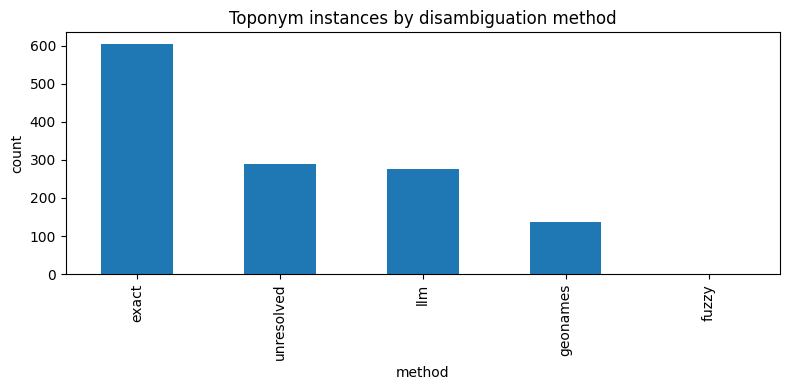

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
disambiguated["disambiguation_method"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Toponym instances by disambiguation method")
ax.set_xlabel("method")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()


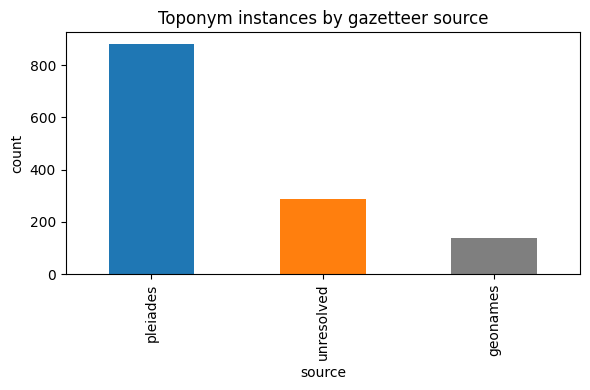

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
disambiguated["gazetteer_source"].value_counts().plot(kind="bar", ax=ax, color=["tab:blue", "tab:orange", "tab:gray"])
ax.set_title("Toponym instances by gazetteer source")
ax.set_xlabel("source")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()


## Interactive map

One `CircleMarker` per unique place: radius scales with `article_count`, colour distinguishes the gazetteer source (blue = Pleiades, orange = GeoNames).

In [10]:
m = folium.Map(location=[41.9, 12.5], zoom_start=5, tiles="cartodbpositron")

for feature in features:
    props = feature["properties"]
    lon, lat = feature["geometry"]["coordinates"]
    if pd.isna(lat) or pd.isna(lon):
        continue

    name = props["pleiades_name"] or props["geonames_name"]
    identifier = props["pleiades_uri"] or props["geonames_id"]
    color = "blue" if props["gazetteer_source"] == "pleiades" else "orange"
    radius = 4 + 2 * (props["article_count"] ** 0.5)

    popup = folium.Popup(
        f"<b>{name}</b><br>{identifier}<br>articles: {props['article_count']}",
        max_width=250,
    )
    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=popup,
    ).add_to(m)

OUT_MAP.parent.mkdir(parents=True, exist_ok=True)
m.save(str(OUT_MAP))
print(f"Saved interactive map to {OUT_MAP}")
m


Saved interactive map to ../data/results/map.html
